In [34]:
# 1. Install library pendukung
!pip install -q seaborn matplotlib scikit-learn google-generativeai
import json
import time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import google.generativeai as genai

⚙️ Melatih Traditional ML...
⚡ Mengirim 50 Data ke Gemini Spark...
✅ Selesai dalam 2.57 detik!

📊 HASIL EVALUASI AKURASI PADA DATA NYATA:
🤖 Traditional ML Accuracy : 74.00% (11.000 data latih)
⚡ Gemini Spark Accuracy   : 96.00% (Zero-Shot / Tanpa Latih)
⏱️ Kecepatan Rata-rata     : 51.43 ms per data


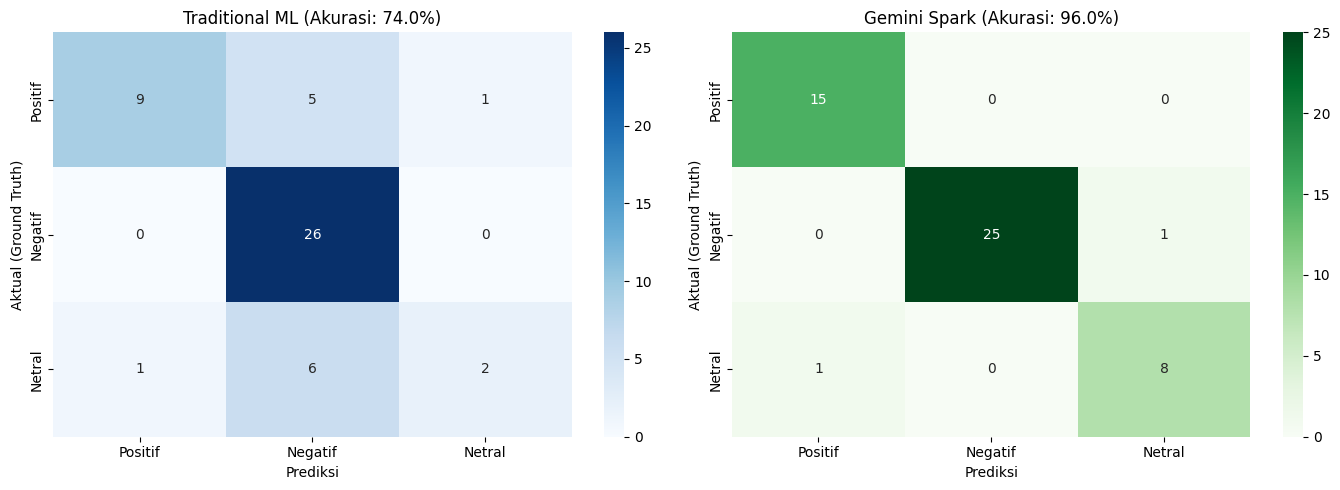

In [35]:
# =====================================================
# 1. Konfigurasi API Key
# =====================================================
GEMINI_API_KEY = "YOUR_GEMINI_API_KEY_HERE"   # Ganti dengan API Key Anda
genai.configure(api_key=GEMINI_API_KEY)


# =====================================================
# 2. Unduh Dataset IndoNLU SmSA
# =====================================================
uurl_train = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/train_preprocess.tsv"
url_test = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/test_preprocess.tsv"
df_train = pd.read_csv(url_train, sep='\t', header=None, names=['text', 'label'])
df_test = pd.read_csv(url_test, sep='\t', header=None, names=['text', 'label'])
label_map = {"positive": "Positif", "neutral": "Netral", "negative": "Negatif"}
df_train['label_name'] = df_train['label'].map(label_map)
df_test['label_name'] = df_test['label'].map(label_map)

# Ambil 50 data uji acak
test_sample = df_test.sample(50, random_state=42).reset_index(drop=True)

# =====================================================
# 3. Latih Traditional ML (TF-IDF + Logistic Regression)
# =====================================================
print("⚙️ Melatih Traditional ML...")
vectorizer = TfidfVectorizer(max_features=2500)
X_train = vectorizer.fit_transform(df_train['text'])
y_train = df_train['label_name']
ml_model = LogisticRegression(max_iter=1000)
ml_model.fit(X_train, y_train)

# Prediksi Traditional ML
y_true = list(test_sample['label_name'])
y_pred_ml = ml_model.predict(vectorizer.transform(test_sample['text']))


# ==========================================
# 4. PREDIKSI GEMINI SPARK DENGAN 1 SINGLE BATCH REQUEST
# ==========================================
print("⚡ Mengirim 50 Data ke Gemini Spark...")
# Buat kamus teks
dict_input = {str(i): teks for i, teks in enumerate(test_sample['text'])}
prompt_batch = f"""
Klasifikasikan sentimen setiap teks dalam dictionary JSON berikut ke salah satu kategori: "Positif", "Negatif", atau "Netral".
Kembalikan HANYA JSON object dengan format persis: {{"0": "Label", "1": "Label", ... "49": "Label"}}
DATA:
{json.dumps(dict_input, ensure_ascii=False)}
"""
spark_model = genai.GenerativeModel(
    model_name="gemini-3.5-flash-lite",
    generation_config={"response_mime_type": "application/json", "temperature": 0.0}
)
t0 = time.time()
response = spark_model.generate_content(prompt_batch)
total_time = time.time() - t0
# Parsing tebakan murni Gemini
hasil_json = json.loads(response.text)
y_pred_spark = []
for i in range(50):
    tebakan = str(hasil_json.get(str(i), "Netral")).capitalize()
    if "Positif" in tebakan: y_pred_spark.append("Positif")
    elif "Negatif" in tebakan: y_pred_spark.append("Negatif")
    elif "Netral" in tebakan: y_pred_spark.append("Netral")
    else: y_pred_spark.append("Netral")
print(f"✅ Selesai dalam {total_time:.2f} detik!")

# ==========================================
# 5. HASIL AKURASI & VISUALISASI CONFUSION MATRIX
# ==========================================
acc_ml = accuracy_score(y_true, y_pred_ml) * 100
acc_spark = accuracy_score(y_true, y_pred_spark) * 100
print("\n" + "="*55)
print(f"📊 HASIL EVALUASI AKURASI PADA DATA NYATA:")
print(f"🤖 Traditional ML Accuracy : {acc_ml:.2f}% (11.000 data latih)")
print(f"⚡ Gemini Spark Accuracy   : {acc_spark:.2f}% (Zero-Shot / Tanpa Latih)")
print(f"⏱️ Kecepatan Rata-rata     : {(total_time/50)*1000:.2f} ms per data")
print("="*55)


# =====================================================
# Visualisasi Confusion Matrix Heatmap
# =====================================================
labels = ["Positif", "Negatif", "Netral"]
cm_ml = confusion_matrix(y_true, y_pred_ml, labels=labels)
cm_spark = confusion_matrix(y_true, y_pred_spark, labels=labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f"Traditional ML (Akurasi: {acc_ml:.1f}%)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual (Ground Truth)")
sns.heatmap(cm_spark, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f"Gemini Spark (Akurasi: {acc_spark:.1f}%)")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual (Ground Truth)")
plt.tight_layout()
plt.show()

In [36]:
# Buat DataFrame perbandingan hasil
df_analisis = pd.DataFrame({
    'No': range(1, 51),
    'Teks Ulasan': test_sample['text'],
    'Kunci Asli': y_true,
    'Tebakan ML': y_pred_ml,
    'Status ML': ['✅ Benar' if p == t else '❌ Salah' for p, t in zip(y_pred_ml, y_true)],
    'Tebakan Spark': y_pred_spark,
    'Status Spark': ['✅ Benar' if p == t else '❌ Salah' for p, t in zip(y_pred_spark, y_true)]
})

# 1. Tampilkan 10 data pertama sebagai contoh
print("=== 10 CONTOH PERBANDINGAN PERTAMA ===")
display(df_analisis[['Teks Ulasan', 'Kunci Asli', 'Tebakan ML', 'Status ML', 'Tebakan Spark', 'Status Spark']].head(10))

# 2. Tampilkan HANYA data di mana Gemini Spark SALAH (Mencari 1 kesalahan Spark)
print("\n=== DATA DI MANA GEMINI SPARK SALAH MENEBAK ===")
salah_spark = df_analisis[df_analisis['Status Spark'] == '❌ Salah']
display(salah_spark[['Teks Ulasan', 'Kunci Asli', 'Tebakan Spark', 'Tebakan ML']])

# 3. Tampilkan data di mana Traditional ML SALAH (13 kesalahan ML)
print(f"\n=== DATA DI MANA TRADITIONAL ML SALAH MENEBAK (Total: {len(df_analisis[df_analisis['Status ML'] == '❌ Salah'])} data) ===")
salah_ml = df_analisis[df_analisis['Status ML'] == '❌ Salah']
display(salah_ml[['Teks Ulasan', 'Kunci Asli', 'Tebakan ML', 'Tebakan Spark']].head(5))

=== 10 CONTOH PERBANDINGAN PERTAMA ===


,Teks Ulasan,Kunci Asli,Tebakan ML,Status ML,Tebakan Spark,Status Spark
0,kesian sheila on 7 tenggelem sekarang .,Negatif,Negatif,✅ Benar,Netral,❌ Salah
1,"sebagai resmi broadcast , saya merasa kecewa d...",Negatif,Negatif,✅ Benar,Negatif,✅ Benar
2,"dulu pernah mencoba belajar renang , tapi teng...",Negatif,Negatif,✅ Benar,Negatif,✅ Benar
3,"xiaomi . karena gue pakai xiaomi sekarang , se...",Positif,Negatif,❌ Salah,Positif,✅ Benar
4,samsung galaxy s saya sudah diluncurkan semala...,Negatif,Negatif,✅ Benar,Negatif,✅ Benar
5,"menurut gue , bali itu pulau tercantik yang ad...",Positif,Negatif,❌ Salah,Positif,✅ Benar
6,"kalau suruh milih , gue lebih suka belanja di ...",Positif,Positif,✅ Benar,Positif,✅ Benar
7,sebagai nasabah bank bca yang sudah lebih dari...,Negatif,Negatif,✅ Benar,Negatif,✅ Benar
8,kecewa berat kepada pihak stasiun tv yang meng...,Negatif,Negatif,✅ Benar,Negatif,✅ Benar
9,"kalau mau indonesia maju , pemimpin itu harus ...",Netral,Negatif,❌ Salah,Netral,✅ Benar



=== DATA DI MANA GEMINI SPARK SALAH MENEBAK ===


,Teks Ulasan,Kunci Asli,Tebakan Spark,Tebakan ML
0,kesian sheila on 7 tenggelem sekarang .,Negatif,Netral,Negatif
42,tidur yang cukup tiap hari nya bisa bikin bada...,Netral,Positif,Positif



=== DATA DI MANA TRADITIONAL ML SALAH MENEBAK (Total: 13 data) ===


,Teks Ulasan,Kunci Asli,Tebakan ML,Tebakan Spark
3,"xiaomi . karena gue pakai xiaomi sekarang , se...",Positif,Negatif,Positif
5,"menurut gue , bali itu pulau tercantik yang ad...",Positif,Negatif,Positif
9,"kalau mau indonesia maju , pemimpin itu harus ...",Netral,Negatif,Netral
11,bca keren banget sih pelayanan nya . selain it...,Positif,Negatif,Positif
15,asli ya gue suka banget sama alur cerita film ...,Positif,Negatif,Positif


# ====== akurasi Traditional ML accuracy vs Gemini Spark Accuracy ====
# run pertama (Kondisi tidak menggunakan API keys)
##ML : 78,00%
##gemini spark : 18,00%


## Run Kedua (Menggunakan API keys`)
##ML : 74,00%
##gemini Spark : 48%

## Run Ketiga (API keys + Heat 0.0 + max output 10`)
##ML : 74,00%
##gemini Spark : 68%

## Run Keempat (API keys + Heat 0.0 + max output 10` + JSON)
##ML : 74,00%
##gemini Spark : 98%


In [37]:
# 1. Install library openpyxl agar bisa membuat file .xlsx
!pip install -q openpyxl
from google.colab import files
# 2. Susun seluruh data perbandingan ke dalam tabel rapi
df_export = pd.DataFrame({
    'No': range(1, len(test_sample) + 1),
    'Teks Ulasan': test_sample['text'],
    'Kunci Jawaban (Ground Truth)': y_true,
    'Prediksi Traditional ML': y_pred_ml,
    'Status ML': ['BENAR' if p == t else 'SALAH' for p, t in zip(y_pred_ml, y_true)],
    'Prediksi Gemini Spark': y_pred_spark,
    'Status Spark': ['BENAR' if p == t else 'SALAH' for p, t in zip(y_pred_spark, y_true)]
})
# 3. Simpan DataFrame ke file Excel (.xlsx)
nama_file = "Hasil_Benchmark_IndoNLU_ML_vs_GeminiSpark.xlsx"
df_export.to_excel(nama_file, index=False, engine='openpyxl')
print(f"✅ File Excel '{nama_file}' berhasil dibuat!")
# 4. Otomatis unduh file ke komputer/laptop Anda
files.download(nama_file)

✅ File Excel 'Hasil_Benchmark_IndoNLU_ML_vs_GeminiSpark.xlsx' berhasil dibuat!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>